In [9]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

# DECODER

In [10]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(ALICE_PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(ALICE_PREDICTOR_DIR / f'~concatenated_predictors.pickle')
models = helper_functions.alice_get_models(exclude=['envelope_log_onset'])
SUBJECTS = helper_functions.alice_get_subjects()

In [11]:
# ------------------------------------------------
# Parameters
# ------------------------------------------------
subject_example = 'S13'  # pick first subject

# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r2_values = {model: [] for model in models}
rmse_values = {model: [] for model in models}

r_values_universal = {model: [] for model in models}
r2_values_universal = {model: [] for model in models}
rmse_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {model: eelbrain.load.unpickle(ALICE_TRF_DIR / f'decoder-universal-trf-{model}.pickle')
                  for model in models}

# ------------------------------------------------
# Loop over subjects and models
# ------------------------------------------------
for subject in SUBJECTS:
    eeg = eelbrain.load.unpickle(ALICE_EEG_DIR / subject / f'{subject}concatenated_eeg.pickle')

    for model in models:
        predictors = subject_model_predictors[subject][model]

        # --- Subject decoder ---
        trf_sub = eelbrain.load.unpickle(ALICE_TRF_DIR / subject / f'{subject} decoder-{model}.pickle')
        pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg).x
        stim_sub = predictors[0]

        r_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1])
        r2_values[model].append(np.corrcoef(stim_sub.x, pred_sub)[0,1]**2)
        rmse_values[model].append(np.sqrt(np.mean((stim_sub.x - pred_sub)**2)))

        # --- Universal decoder ---
        trf_univ = universal_trfs[model]
        pred_univ = eelbrain.convolve(trf_univ, eeg).x
        stim_univ = predictors[0]

        r_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1])
        r2_values_universal[model].append(np.corrcoef(stim_univ.x, pred_univ)[0,1]**2)
        rmse_values_universal[model].append(np.sqrt(np.mean((stim_univ.x - pred_univ)**2)))

# ------------------------------------------------
# Store time series for example subject
# ------------------------------------------------
eeg_example = eelbrain.load.unpickle(ALICE_EEG_DIR / subject_example / f'{subject_example}concatenated_eeg.pickle')
time_series_example = {}

for model in ['envelope_log', 'envelope_onset']:
    # subject TRF
    trf_sub = eelbrain.load.unpickle(ALICE_TRF_DIR / subject_example / f'{subject_example} decoder-{model}.pickle')
    pred_sub = eelbrain.convolve(trf_sub.h_scaled, eeg_example).x
    if pred_sub.ndim > 1:
        pred_sub = pred_sub[0]
    time_series_example[f'Subj {model}'] = pred_sub

    # universal TRF
    trf_univ = universal_trfs[model]
    pred_univ = eelbrain.convolve(trf_univ, eeg_example).x
    if pred_univ.ndim > 1:
        pred_univ = pred_univ[0]
    time_series_example[f'Univ {model}'] = pred_univ

true_env_example = subject_model_predictors[subject_example]['envelope_log'][0].x
time_example = subject_model_predictors[subject_example]['envelope_log'][0].time.times

print("✅ All values computed and stored.")

✅ All values computed and stored.


[np.float64(0.20935536720824582), np.float64(0.08503280443081941), np.float64(0.11118417622830985), np.float64(0.045255005301564045)]


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84491/2209115069.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84491/2209115069.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


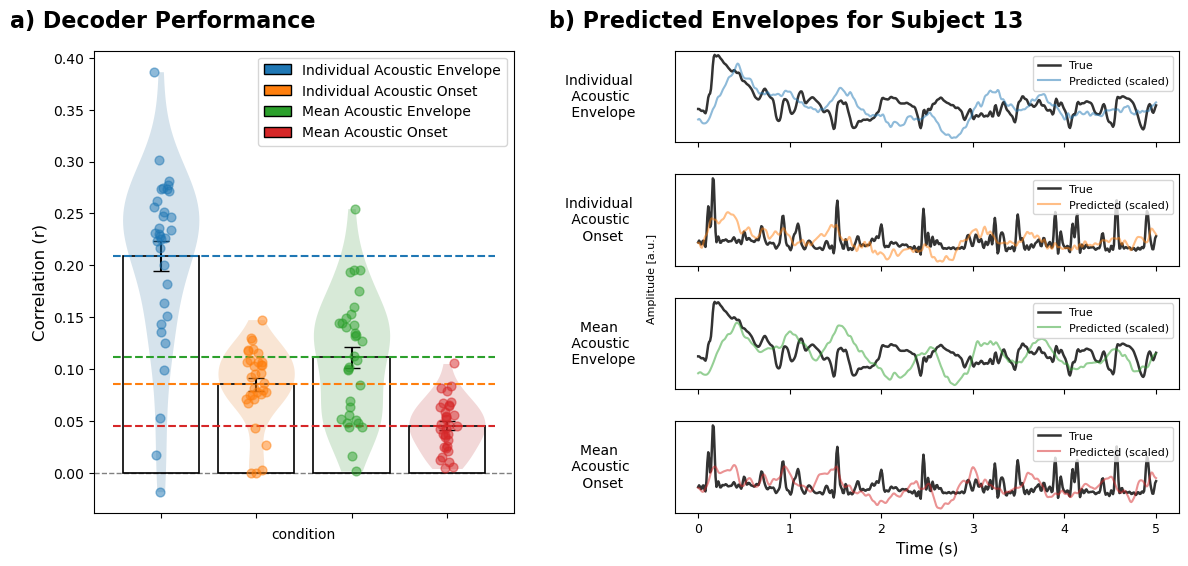

In [12]:
t_max = 5  # seconds to show in panel B

# ------------------------------------------------
# Color palette for consistency
# ------------------------------------------------
trace_colors = sns.color_palette("tab10", n_colors=4)  # for panel B traces
label_colors = trace_colors  # map to panel A scatter points
color_alpha = 0.5

# ------------------------------------------------
# PANEL A: Bar plot with grey bars, semi-transparent scatter, horizontal mean lines
# ------------------------------------------------
'''
labels = ['Subj Log', 'Subj Onset', 'Univ Log', 'Univ Onset']
label_name = {'Subj Log': 'Individual Acoustic Envelope', 
              'Subj Onset': 'Individual Acoustic Onset', 
              'Univ Log': 'Mean Acoustic Envelope', 
              'Univ Onset': 'Mean Acoustic Onset'}
'''
labels = ['Individual Acoustic Envelope', 'Individual Acoustic Onset', 'Mean Acoustic Envelope', 'Mean Acoustic Onset']
data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
print(means)
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.35)

# Bar plot
ax0 = fig.add_subplot(gs[0])
x = np.arange(len(labels))

import pandas as pd

# ----------------------------------------
# Prepare dataframe for seaborn
# ----------------------------------------
df = pd.DataFrame({
    'value': np.concatenate(data),
    'condition': np.repeat(labels, [len(d) for d in data])
})

# ----------------------------------------
# VIOLIN (background)
# ----------------------------------------
sns.violinplot(
    data=df,
    x='condition',
    y='value',
    ax=ax0,
    palette=trace_colors,   # color per condition
    inner=None,
    cut=0,
    linewidth=0,
    alpha=0.2
)

# ----------------------------------------
# BARS (outline only, on top)
# ----------------------------------------
ax0.bar(
    x, means, yerr=sems, capsize=6,
    color='none', edgecolor='k',
    linewidth=1.2, zorder=2
)

# ----------------------------------------
# MEAN LINES + SCATTER
# ----------------------------------------
for i, d in enumerate(data):

    ax0.hlines(
        means[i], xmin=-0.5, xmax=len(labels)-0.5,
        color=trace_colors[i], linestyle='--',
        linewidth=1.5, zorder=3
    )

    ax0.scatter(
        np.random.normal(i, 0.05, size=len(d)), d,
        color=trace_colors[i],
        alpha=color_alpha,
        s=40,
        zorder=4
    )


ax0.set_xticks(x)
ax0.set_xticklabels([], rotation=25)
ax0.set_ylabel('Correlation (r)', fontsize=12)
#ax0.set_title('Panel A: Decoder Performance', fontsize=14)
ax0.axhline(0, linestyle='--', color='gray', linewidth=1, zorder=0)

# Legend inside panel A (upper right)
legend_elements = [Patch(facecolor=trace_colors[i], edgecolor='k', label=labels[i]) for i in range(4)]
ax0.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Add label "a)"
ax0.text(-0.2, 1.05, 'a) Decoder Performance', transform=ax0.transAxes, fontsize=16, fontweight='bold')

# ------------------------------------------------
# PANEL B: Four stacked mini-plots withsignals and 
# ------------------------------------------------

mask = time_example <= t_max
time_50 = time_example[mask]

gs_right = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[1], hspace=0.35)
plot_keys = ['Subj envelope_log', 'Subj envelope_onset', 'Univ envelope_log', 'Univ envelope_onset']

for i, key in enumerate(plot_keys):
    ax = fig.add_subplot(gs_right[i])
    if 'log' in key.lower():
        pred = time_series_example[f'Subj envelope_log'] if 'Subj' in key else time_series_example[f'Univ envelope_log']
        true_env_example = subject_model_predictors[subject_example]['envelope_log'][0].x
    else:
        pred = time_series_example[f'Subj envelope_onset'] if 'Subj' in key else time_series_example[f'Univ envelope_onset']
        true_env_example = subject_model_predictors[subject_example]['envelope_onset'][0].x
    
    env_50 = true_env_example[mask]
    pred_masked = pred[:len(env_50)]
    pred_scaled = pred_masked * (np.std(env_50) / np.std(pred_masked))

    ax.plot(time_50, env_50, label='True', color='black', linewidth=1.8, alpha=0.8)
    ax.plot(time_50, pred_scaled, label='Predicted (scaled)', color=trace_colors[i], linewidth=1.5, alpha=color_alpha)

    labels = ['Individual \n Acoustic \n Envelope', 'Individual \n Acoustic \n Onset', 'Mean \n Acoustic \n Envelope', 'Mean \n Acoustic \n Onset']
    ax.set_ylabel(labels[i], rotation=0, labelpad=50, fontsize=10, va='center')
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=0)  # hides tick marks too

    ax.legend(fontsize=8, loc='upper right')

    if i < 3:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.tick_params(axis='x', labelsize=9)

if i == 3:
    ax.set_xlabel('Time (s)', fontsize=11)
else:
    ax.set_xticklabels([])
# Shared y-axis label for all 4 mini-plots
fig.text(0.52, 0.5, 'Amplitude [a.u.]', va='center', rotation=90, fontsize=8)

# Add label "b)"
ax = fig.add_subplot(gs[1])
ax.text(-0.25, 1.05, 'b) Predicted Envelopes for Subject 13', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.axis('off')  # hide this temporary axis

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig(ALICE_FIGURES_DIR / 'alice-sub13-backward-performance.png', dpi=300)
plt.show()


In [13]:
# =================================================
# PAIRED T-TESTS
# =================================================
res1 = helper_functions.paired_ttest(r_values['envelope_log'], r_values['envelope_onset'])
res2 = helper_functions.paired_ttest(r_values['envelope_log'], r_values_universal['envelope_log'])
res3 = helper_functions.paired_ttest(r_values['envelope_onset'], r_values_universal['envelope_onset'])
res4 = helper_functions.paired_ttest(r_values_universal['envelope_log'], r_values_universal['envelope_onset'])

t1, p1 = res1['t'], res1['p']
t2, p2 = res2['t'], res2['p']
t3, p3 = res3['t'], res3['p']
t4, p4 = res4['t'], res4['p']

print("\n--- Paired t-tests ---")
print(f"Individual Envelope vs Individual Onset: t = {t1:.3f}, p = {p1:.6e}")
print(f"Individual Envelope vs Mean Envelope: t = {t2:.3f}, p = {p2:.6e}")
print(f"Individual Onset vs Mean Onset: t = {t3:.3f}, p = {p3:.6e}")
print(f"Mean Envelope vs Mean Onset: t = {t4:.3f}, p = {p4:.6e}")


# =================================================
# ONE-SAMPLE T-TESTS VS CHANCE (r = 0)
# =================================================
print("\n--- One-sample t-tests vs 0 (chance) ---")

conditions = {
    "Individual Envelope": r_values['envelope_log'],
    "Individual Onset": r_values['envelope_onset'],
    "Mean Envelope": r_values_universal['envelope_log'],
    "Mean Onset": r_values_universal['envelope_onset']
}

for name, values in conditions.items():
    test = helper_functions.one_sample_ttest(values)
    t = test["t"]
    p = test["p"]
    print(f"{name}: t = {t:.3f}, p = {p:.6e}")


# =================================================
# PERMUTATION TEST (SIGN-FLIP VERSION) VS CHANCE (r = 0)
# =================================================
print("\n--- Permutation tests (vs chance) ---")

for name, values in conditions.items():
    test = helper_functions.sign_flip_permutation(values, n_permutations=10000, alternative='greater')
    mean_obs = test["observed_mean_r"]
    null_dist = test["null_distribution"]
    p_perm = test["p"]
    print(f"{name}: mean = {mean_obs:.4f}, null mean = {np.mean(null_dist):.4f}, perm p = {p_perm:.6e}")



--- Paired t-tests ---
Individual Envelope vs Individual Onset: t = 12.780, p = 4.095835e-14
Individual Envelope vs Mean Envelope: t = 12.004, p = 2.175107e-13
Individual Onset vs Mean Onset: t = 10.434, p = 7.937368e-12
Mean Envelope vs Mean Onset: t = 10.018, p = 2.168563e-11

--- One-sample t-tests vs 0 (chance) ---
Individual Envelope: t = 14.009, p = 1.671882e-15
Individual Onset: t = 13.295, p = 7.036320e-15
Mean Envelope: t = 10.774, p = 1.773809e-12
Mean Onset: t = 10.636, p = 2.457256e-12

--- Permutation tests (vs chance) ---
Individual Envelope: mean = 0.2107, null mean = 0.0002, perm p = 0.000000e+00
Individual Onset: mean = 0.0851, null mean = 0.0001, perm p = 0.000000e+00
Mean Envelope: mean = 0.1116, null mean = 0.0002, perm p = 0.000000e+00
Mean Onset: mean = 0.0453, null mean = 0.0001, perm p = 0.000000e+00


# ENCODER

In [14]:
# ------------------------------------------------
# Storage
# ------------------------------------------------
r_values = {model: [] for model in models}
r_values_universal = {model: [] for model in models}

# Load universal TRFs
universal_trfs = {
    model: eelbrain.load.unpickle(ALICE_TRF_DIR / f'universal-trf-{model}.pickle')
    for model in models
}

# ------------------------------------------------
# Loop over subjects
# ------------------------------------------------
for subject in SUBJECTS:

    eeg = eelbrain.load.unpickle(ALICE_EEG_DIR / subject /f'{subject}concatenated_eeg.pickle')
    eeg_data = eeg.x

    for model in models:

        predictors = subject_model_predictors[subject][model]

        # ----------------------------------------
        # Subject encoder
        # ----------------------------------------
        trf_sub = eelbrain.load.unpickle(
            ALICE_TRF_DIR / subject / f'{subject} {model}.pickle'
        )

        pred_sub = eelbrain.convolve(trf_sub.h_scaled, predictors).x

        r_channels = []
        for ch in range(eeg_data.shape[0]):
            if np.std(eeg_data[ch]) > 0 and np.std(pred_sub[ch]) > 0:
                r_channels.append(np.corrcoef(eeg_data[ch], pred_sub[ch])[0,1])

        if len(r_channels) > 0:
            r_values[model].append(np.mean(r_channels))

        # ----------------------------------------
        # Universal encoder
        # ----------------------------------------
        trf_univ = universal_trfs[model]

        pred_univ = eelbrain.convolve(trf_univ, predictors[0]).x

        r_channels = []
        for ch in range(eeg_data.shape[0]):
            if np.std(eeg_data[ch]) > 0 and np.std(pred_univ[ch]) > 0:
                r_channels.append(np.corrcoef(eeg_data[ch], pred_univ[ch])[0,1])

        if len(r_channels) > 0:
            r_values_universal[model].append(np.mean(r_channels))

print("✅ Encoder values computed")


✅ Encoder values computed


[np.float64(0.05485343875922642), np.float64(0.04172346773473096), np.float64(0.03789593946628108), np.float64(0.0313808318385242)]


/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84491/168918529.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/q5/dlf_55750jq9b22jkpyf6c940000gn/T/ipykernel_84491/168918529.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


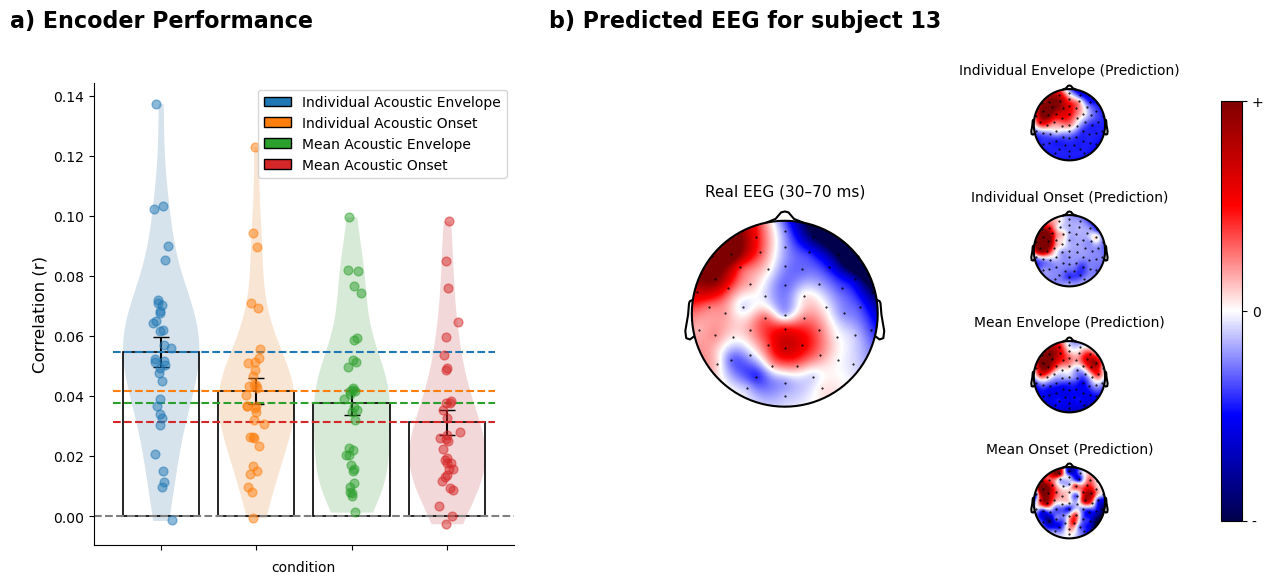

In [15]:
# ------------------------------------------------
# Colors
# ------------------------------------------------
colors = sns.color_palette("tab10", 4)
alpha = 0.5

# ------------------------------------------------
# FIGURE + MASTER GRID
# ------------------------------------------------
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.35)

# =================================================
# PANEL A — BAR PLOT
# =================================================
ax0 = fig.add_subplot(gs[0])

labels = [
    'Individual Acoustic Envelope',
    'Individual Acoustic Onset',
    'Mean Acoustic Envelope',
    'Mean Acoustic Onset'
]

data = [
    r_values['envelope_log'],
    r_values['envelope_onset'],
    r_values_universal['envelope_log'],
    r_values_universal['envelope_onset']
]

means = [np.mean(d) for d in data]
print(means)
sems = [np.std(d)/np.sqrt(len(d)) for d in data]

x = np.arange(len(labels))

# ----------------------------------------
# Prepare data for seaborn
# ----------------------------------------
import pandas as pd

df = pd.DataFrame({
    'value': np.concatenate(data),
    'condition': np.repeat(labels, [len(d) for d in data])
})

# ----------------------------------------
# VIOLIN (background distribution)
# ----------------------------------------
sns.violinplot(
    data=df,
    x='condition',
    y='value',
    ax=ax0,
    inner=None,
    palette=colors,
    linewidth=0,
    cut=0,
    alpha=0.2
)

# ----------------------------------------
# BARS (on top)
# ----------------------------------------
ax0.bar(
    x, means, yerr=sems, capsize=6,
    color='none', edgecolor='k',
    linewidth=1.2, zorder=2
)

# ----------------------------------------
# SCATTER + MEAN LINES
# ----------------------------------------
for i, d in enumerate(data):

    ax0.hlines(
        means[i], -0.5, len(labels)-0.5,
        color=colors[i], linestyle='--',
        linewidth=1.5, zorder=3
    )

    ax0.scatter(
        np.random.normal(i, 0.05, len(d)), d,
        color=colors[i], alpha=alpha,
        s=40, zorder=4
    )


ax0.set_ylabel('Correlation (r)', fontsize=12)
ax0.set_xticks(x)
ax0.set_xticklabels([])

ax0.axhline(0, linestyle='--', color='gray')

# clean look
ax0.spines[['top', 'right']].set_visible(False)

# legend
legend = [Patch(facecolor=colors[i], edgecolor='k', label=labels[i]) for i in range(4)]
ax0.legend(handles=legend, fontsize=10, loc='upper right')

# panel label (raised higher)
ax0.text(
    -0.2, 1.12,
    'a) Encoder Performance',
    transform=ax0.transAxes,
    fontsize=16,
    fontweight='bold'
)

# =================================================
# PANEL B — TOPOMAPS (IMPROVED DESIGN)
# =================================================
gs_right = gridspec.GridSpecFromSubplotSpec(
    4, 2,
    subplot_spec=gs[1],
    width_ratios=[1, 1],   # keep balanced
    wspace=0.3,
    hspace=0.5
)

subject_example = 'S13'

eeg = eelbrain.load.unpickle(
    ALICE_EEG_DIR / f'{subject_example}' / f'{subject_example}concatenated_eeg.pickle'
)

titles = [
    ('Subj envelope_log', 'Individual Envelope'),
    ('Subj envelope_onset', 'Individual Onset'),
    ('Univ envelope_log', 'Mean Envelope'),
    ('Univ envelope_onset', 'Mean Onset')
]

# shared color scale
vmin, vmax = -2, 2

# -----------------------------------------
# REAL EEG (ONE BIG TOPOMAP)
# -----------------------------------------
tmin, tmax = 0.03, 0.07
time = eeg.time.times
mask = (time >= tmin) & (time <= tmax)

real_window = eeg.x[:, mask].mean(axis=1)
real_z = scipy.stats.zscore(real_window)
real_map = eelbrain.NDVar(real_z, dims=(eeg.sensor,))

# span all rows (big plot)
ax_real_big = fig.add_subplot(gs_right[:, 0])

eelbrain.plot.Topomap(real_map, axes=ax_real_big, vmin=vmin, vmax=vmax, cmap="seismic", clip="circle")
ax_real_big.set_title('Real EEG (30–70 ms)', fontsize=11)

# -----------------------------------------
# PREDICTED MAPS (RIGHT COLUMN)
# -----------------------------------------
for i, (key, label) in enumerate(titles):

    model = key.split()[-1]
    stimulus = subject_model_predictors[subject_example][model]

    # SUBJECT
    if 'Subj' in key:
        trf = eelbrain.load.unpickle(
            ALICE_TRF_DIR / subject_example / f'{subject_example} {model}.pickle'
        )
        pred = eelbrain.convolve(trf.h_scaled, stimulus)

    # UNIVERSAL
    else:
        trf = eelbrain.load.unpickle(
            ALICE_TRF_DIR / f'universal-trf-{model}.pickle'
        )
        pred = eelbrain.convolve(trf, stimulus[0])

    pred_window = pred.x[:, mask].mean(axis=1)
    pred_z = scipy.stats.zscore(pred_window)
    pred_map = eelbrain.NDVar(pred_z, dims=(pred.sensor,))

    ax_pred = fig.add_subplot(gs_right[i, 1])

    topo_plot = eelbrain.plot.Topomap(pred_map, axes=ax_pred, vmin=vmin, vmax=vmax, cmap="seismic", clip="circle")
    ax_pred.set_title(f'{label} (Prediction)', fontsize=10)


# ------------------------------------------------
# SHARED COLORBAR
# ------------------------------------------------
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

trf_vmax = 1
sm = matplotlib.cm.ScalarMappable(cmap='seismic', norm=matplotlib.colors.Normalize(vmin=-trf_vmax, vmax=trf_vmax))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([-trf_vmax, 0, trf_vmax])
cbar.set_ticklabels(['-', '0', '+'])


# ------------------------------------------------
# PANEL B LABEL (raised higher)
# ------------------------------------------------
ax_label = fig.add_subplot(gs[1])
ax_label.text(
    -0.25, 1.12,
    'b) Predicted EEG for subject 13',
    transform=ax_label.transAxes,
    fontsize=16,
    fontweight='bold'
)
ax_label.axis('off')

# ------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------
plt.tight_layout(rect=[0, 0, 0.92, 1])

plt.savefig(ALICE_FIGURES_DIR / 'alice-sub13-forward-performance.png', dpi=300)

plt.show()

In [16]:
# =================================================
# PAIRED T-TESTS
# =================================================
res1 = helper_functions.paired_ttest(r_values['envelope_log'], r_values['envelope_onset'])
res2 = helper_functions.paired_ttest(r_values['envelope_log'], r_values_universal['envelope_log'])
res3 = helper_functions.paired_ttest(r_values['envelope_onset'], r_values_universal['envelope_onset'])
res4 = helper_functions.paired_ttest(r_values_universal['envelope_log'], r_values_universal['envelope_onset'])

t1, p1 = res1['t'], res1['p']
t2, p2 = res2['t'], res2['p']
t3, p3 = res3['t'], res3['p']
t4, p4 = res4['t'], res4['p']

print("\n--- Paired t-tests ---")
print(f"Individual Envelope vs Individual Onset: t = {t1:.3f}, p = {p1:.6e}")
print(f"Individual Envelope vs Mean Envelope: t = {t2:.3f}, p = {p2:.6e}")
print(f"Individual Onset vs Mean Onset: t = {t3:.3f}, p = {p3:.6e}")
print(f"Mean Envelope vs Mean Onset: t = {t4:.3f}, p = {p4:.6e}")


# =================================================
# ONE-SAMPLE T-TESTS VS CHANCE (r = 0)
# =================================================
print("\n--- One-sample t-tests vs 0 (chance) ---")

conditions = {
    "Individual Envelope": r_values['envelope_log'],
    "Individual Onset": r_values['envelope_onset'],
    "Mean Envelope": r_values_universal['envelope_log'],
    "Mean Onset": r_values_universal['envelope_onset']
}

for name, values in conditions.items():
    test = helper_functions.one_sample_ttest(values)
    t = test["t"]
    p = test["p"]
    print(f"{name}: t = {t:.3f}, p = {p:.6e}")


# =================================================
# PERMUTATION TEST (SIGN-FLIP VERSION — BEST HERE)
# =================================================

print("\n--- Permutation tests (vs chance) ---")

for name, values in conditions.items():
    test = helper_functions.sign_flip_permutation(values, n_permutations=10000, alternative='greater')
    mean_obs = test["observed_mean_r"]
    null_dist = test["null_distribution"]
    p_perm = test["p"]
    print(f"{name}: mean = {mean_obs:.4f}, null mean = {np.mean(null_dist):.4f}, perm p = {p_perm:.6e}")


--- Paired t-tests ---
Individual Envelope vs Individual Onset: t = 8.522, p = 9.739104e-10
Individual Envelope vs Mean Envelope: t = 8.157, p = 2.573355e-09
Individual Onset vs Mean Onset: t = 7.044, p = 5.488863e-08
Mean Envelope vs Mean Onset: t = 4.945, p = 2.333980e-05

--- One-sample t-tests vs 0 (chance) ---
Individual Envelope: t = 10.778, p = 1.758432e-12
Individual Onset: t = 9.254, p = 7.288530e-11
Mean Envelope: t = 8.652, p = 3.450917e-10
Mean Onset: t = 7.420, p = 9.614858e-09

--- Permutation tests (vs chance) ---
Individual Envelope: mean = 0.0549, null mean = 0.0000, perm p = 0.000000e+00
Individual Onset: mean = 0.0418, null mean = 0.0000, perm p = 0.000000e+00
Mean Envelope: mean = 0.0379, null mean = 0.0001, perm p = 0.000000e+00
Mean Onset: mean = 0.0314, null mean = 0.0000, perm p = 0.000000e+00
